In [39]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

In [2]:
model_name = "resnet18"

In [12]:
main_path = Path("../../jetson/power_logging/raw_data") / model_name
ablated_paths = [path for path in main_path.iterdir() if path.is_dir() and path.name.startswith("ablate")]
log_name = f"{model_name}_power_log.log"

In [30]:
main_df = pd.read_csv(main_path / log_name, names=["time", "voltage", "current"], parse_dates=[0])
ablated_dfs = {path.name: pd.read_csv(path / log_name, names=["time", "voltage", "current"], parse_dates=[0]) for path in ablated_paths}

In [46]:
idle_power = 4148813.0

main_df["power"] = main_df.current * main_df.voltage - idle_power
for df in ablated_dfs.values():
    df["power"] = df.current * df.voltage - idle_power

# Data analysis

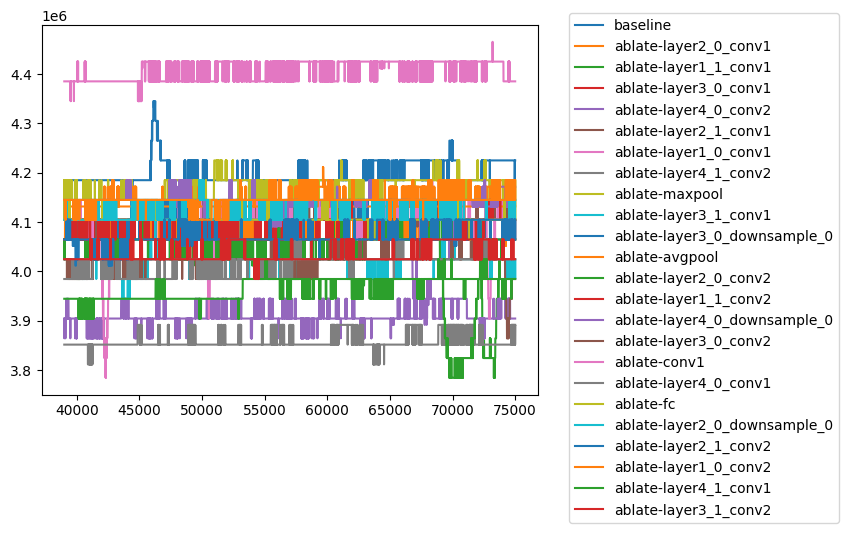

In [47]:
a = 39000
b = 75000

main_df.iloc[a:b].power.plot(label="baseline")
for key, df in ablated_dfs.items():
    df.iloc[a:b].power.plot(label=key)
    
plt.legend(bbox_to_anchor=(1.05, 1.05))
plt.show()

Observations:
* There's definitely a difference between the baseline and ablated networks in terms of power draw
* However, ablate-conv1 network draws more power, which suggests that ablation may not be performed correctly

In [48]:
stats = {"baseline": main_df.iloc[a:b].power.describe()}
for key, df in ablated_dfs.items():
    stats[key] = df.iloc[a:b].power.describe()

stats_df = pd.DataFrame(stats).T

In [49]:
stats_df

,count,mean,std,min,25%,50%,75%,max
baseline,36000.0,4.198585e+06,23820.908077,4144435.0,4184499.0,4184499.0,4224563.0,4344755.0
ablate-layer2_0_conv1,36000.0,4.084688e+06,20006.215758,4051187.0,4064307.0,4104371.0,4104371.0,4144435.0
ablate-layer1_1_conv1,36000.0,4.048014e+06,45366.669901,3783859.0,4024243.0,4064307.0,4064307.0,4104371.0
ablate-layer3_0_conv1,36000.0,4.098750e+06,15443.320868,4064307.0,4104371.0,4104371.0,4104371.0,4144435.0
ablate-layer4_0_conv2,36000.0,3.908567e+06,19721.506987,3863987.0,3904051.0,3904051.0,3904051.0,3984179.0
ablate-layer2_1_conv1,36000.0,4.106890e+06,10154.599985,4064307.0,4104371.0,4104371.0,4104371.0,4144435.0
ablate-layer1_0_conv1,36000.0,4.107193e+06,43808.878512,3783859.0,4104371.0,4104371.0,4144435.0,4184499.0
ablate-layer4_1_conv2,36000.0,3.856738e+06,14976.732193,3811187.0,3851187.0,3851187.0,3851187.0,3891187.0
ablate-maxpool,36000.0,4.168069e+06,21346.303721,4104371.0,4144435.0,4184499.0,4184499.0,4224563.0
ablate-layer3_1_conv1,36000.0,4.019727e+06,16057.194173,3944115.0,4024243.0,4024243.0,4024243.0,4104371.0


In [55]:
median_difference = stats_df["50%"].baseline - stats_df["50%"]
median_difference

baseline                             0.0
ablate-layer2_0_conv1            80128.0
ablate-layer1_1_conv1           120192.0
ablate-layer3_0_conv1            80128.0
ablate-layer4_0_conv2           280448.0
ablate-layer2_1_conv1            80128.0
ablate-layer1_0_conv1            80128.0
ablate-layer4_1_conv2           333312.0
ablate-maxpool                       0.0
ablate-layer3_1_conv1           160256.0
ablate-layer3_0_downsample_0     80128.0
ablate-avgpool                   53312.0
ablate-layer2_0_conv2           120192.0
ablate-layer1_1_conv2            80128.0
ablate-layer4_0_downsample_0     40064.0
ablate-layer3_0_conv2           160256.0
ablate-conv1                   -200320.0
ablate-layer4_0_conv1           160256.0
ablate-fc                        80128.0
ablate-layer2_0_downsample_0     40064.0
ablate-layer2_1_conv2           120192.0
ablate-layer1_0_conv2            40064.0
ablate-layer4_1_conv1           200320.0
ablate-layer3_1_conv2           160256.0
Name: 50%, dtype

Observations:


In [58]:
unexplained = stats_df["50%"].baseline - median_difference.drop("ablate-conv1").sum()

In [66]:
unexplained / stats_df["50%"].baseline

np.float64(0.39058893310764325)

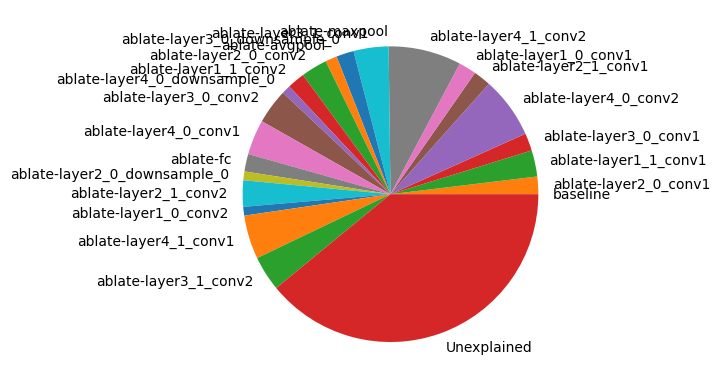

In [65]:
plt.pie(list(median_difference.drop("ablate-conv1").values) + [unexplained], labels = list(median_difference.drop("ablate-conv1").index) + ["Unexplained"])
plt.show()

Similar conclusions about ablation being incorrect can be drawn here, as the total reduction in power draw is nowhere near the total power consumption.